In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from CosinorPy import file_parser, cosinor, cosinor1, cosinor_nonlin
import seaborn as sns


# High Resolution Data Analysis

In this notebooks we are going to import the High Resolution Dataset from ``Replication Data for: High resolution daily profiles of tissue adrenal steroids by portable automated collection'' and perform some initial analysis and feature extraction in order to create new nodes and edges for the graph model.  The dataset contains high resolution steroid data from 213 patients taken over a 72 hr period.  The readings are taken every 20 mins.  We will focus mainly on cortisol readings.

Upton, T., Zavala, E., Methlie, P., Kämpe, O., Tsagarakis, S., Øksnes, M., Bensing, S., Vassiliadi, D., Grytaas, M., Botusan, I., Ueland, G., Berinder, K., Simunkova, K., Balomenaki, M., Margaritopoulos, D., Henne, N., Crossley, R., Russell, G., Husebye, E., & Lightman, S. L. (2023). Replication Data for: High resolution daily profiles of tissue adrenal steroids by portable automated collection (https://doi.org/10.18710/5TW8YF 



In [2]:
highResData = pd.read_csv('./data/high-resolution/md_data_controls.csv')
highResData

,MasterID,SampleTime,SampleNo,18oxoF,18OHF,Aldo,Cortisol,Cortisone,18OHCCS,DHEAS,...,Andro,11deoxyCCS,Testo,DHEA,17OHP,EpiTesto,DHT,Prog,F E,F F+E
0,71,01/01/2000 11:40,1,NaN,383.252,64.825,2.920,3.722,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.784524,0.439627
1,71,02/01/2000 04:40,52,NaN,45.905,NaN,0.661,0.738,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.895664,0.472480
2,71,02/01/2000 04:20,51,NaN,49.365,NaN,0.652,0.725,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.899310,0.473493
3,71,02/01/2000 04:00,50,NaN,48.270,NaN,0.562,0.654,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.859327,0.462171
4,71,02/01/2000 03:40,49,NaN,35.402,NaN,0.400,0.470,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.851064,0.459770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15403,5127,01/01/2000 18:20,23,NaN,202.331,9.677,3.469,3.972,NaN,11.844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.873364,0.466201
15404,5127,01/01/2000 18:00,22,NaN,208.005,10.430,3.414,3.771,NaN,9.848,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.905330,0.475157
15405,5127,01/01/2000 17:40,21,NaN,235.598,11.000,3.242,3.377,NaN,9.103,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.960024,0.489802
15406,5127,01/01/2000 19:40,27,NaN,154.096,6.916,2.361,3.062,NaN,11.364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.771065,0.435368


### The dataset contains the following columns:

In [3]:
highResData.columns

Index(['MasterID', 'SampleTime', 'SampleNo', '18oxoF', '18OHF', 'Aldo',
       'Cortisol', 'Cortisone', '18OHCCS', 'DHEAS', '21DOC', '11DOC', 'CCS',
       'aTHF', 'THF', 'aTHE', 'THE', 'DXM', 'THAldo', 'Andro', '11deoxyCCS',
       'Testo', 'DHEA', '17OHP', 'EpiTesto', 'DHT', 'Prog', 'F E', 'F F+E'],
      dtype='object')

### and unique patient ids

In [4]:
highResData['MasterID'].unique()

array([  71,   73,   75,  115,  125,  127,  129,  135,  137,  139,  141,
        143,  145,  155,  157,  159,  169,  171,  173,  181,  183,  185,
        191,  193,  203,  211,  225,  227,  229,  231,  235,  237,  239,
        241,  247,  255,  257,  263,  265,  267,  271,  275,  285,  289,
        291,  293,  301,  303,  305,  307,  317,  321,  323,  329,  331,
        333,  335,  341,  345,  351,  353,  357,  361,  365,  367,  377,
        379,  391,  407,  427,  437,  447,  451,  463,  465,  469,  487,
        491,  497,  503,  505,  517,  519,  525,  527,  529,  531,  541,
        553,  563,  565,  571,  579,  583,  585,  587,  595,  605,  611,
        615,  617,  645,  649,  653,  655,  659,  661,  663,  665,  669,
        671,  673,  679,  681,  683,  687,  695,  699,  707,  713,  717,
        721,  725,  727,  729,  735,  747,  751,  753,  761,  763,  769,
        771,  787,  793,  795,  803,  805,  807,  811,  817,  821,  823,
        825,  835,  837,  845,  855,  857,  859,  8

### Data preprocessing

- time - The datetime values need converting to pandas datatime, to pandas time and to floats corresponding with the hours in the day.
- Cortisol - The cortisol values need to be interpolated to fill in any missing values.
- 180HF - The 18OHF values need to be interpolated to fill in any missing values.
- Cortisone - The cortisone values need to be interpolated to fill in any missing values. 
- CortisolGradient - The gradient of the cortisol values needs to be calculated, the first value of each group should be set to 0.
- datetime - For ease of processing, we're going to sort the values by datetime (as we will be grouping by MasterID later on).

In [5]:
def get_time(datetime):
    return datetime.strftime('%H:%M')
    
highResDataUpdated = pd.read_csv('./data/high-resolution/md_data_controls.csv')
highResDataUpdated['datetime'] = pd.to_datetime(highResDataUpdated['SampleTime'], format='%d/%m/%Y %H:%M')
highResDataUpdated['Cortisol'] = highResDataUpdated['Cortisol'].interpolate(method='linear')
highResDataUpdated['18OHF'] = highResDataUpdated['18OHF'].interpolate(method='linear')
highResDataUpdated['Cortisone'] = highResDataUpdated['Cortisone'].interpolate(method='linear')
highResDataUpdated.reset_index(inplace=True)
highResDataUpdated['CortisolGradient'] = np.gradient(highResDataUpdated['Cortisol'])
highResDataUpdated.loc[highResDataUpdated.groupby('MasterID').head(1).index, 'CortisolGradient'] = 0 # Set gradient the first value of each group to 0
highResDataUpdated['time'] = highResDataUpdated['datetime'].dt.time
highResDataUpdated['timeFloat'] = highResDataUpdated['datetime'].dt.hour + highResDataUpdated['datetime'].dt.minute / 60.0

highResDataUpdated = highResDataUpdated.sort_values(by='datetime')
highResDataUpdated[highResDataUpdated['MasterID'] == 71]

,index,MasterID,SampleTime,SampleNo,18oxoF,18OHF,Aldo,Cortisol,Cortisone,18OHCCS,...,17OHP,EpiTesto,DHT,Prog,F E,F F+E,datetime,CortisolGradient,time,timeFloat
0,0,71,01/01/2000 11:40,1,NaN,383.252,64.825,2.9200,3.722,NaN,...,NaN,NaN,NaN,NaN,0.784524,0.439627,2000-01-01 11:40:00,0.00000,11:40:00,11.666667
51,51,71,01/01/2000 12:00,2,NaN,398.259,68.065,3.3620,4.186,NaN,...,NaN,NaN,NaN,NaN,0.803153,0.445416,2000-01-01 12:00:00,-1.39950,12:00:00,12.000000
50,50,71,01/01/2000 12:20,3,NaN,512.285,93.487,4.4620,5.586,NaN,...,NaN,NaN,NaN,NaN,0.798783,0.444068,2000-01-01 12:20:00,-1.37100,12:20:00,12.333333
49,49,71,01/01/2000 12:40,4,NaN,473.744,104.868,6.1040,7.045,NaN,...,NaN,NaN,NaN,NaN,0.866430,0.464218,2000-01-01 12:40:00,-0.96275,12:40:00,12.666667
48,48,71,01/01/2000 13:00,5,NaN,446.046,NaN,6.3875,7.385,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2000-01-01 13:00:00,-0.28350,13:00:00,13.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,23,71,02/01/2000 10:00,68,NaN,246.499,13.450,4.3640,3.272,NaN,...,NaN,NaN,NaN,NaN,1.333741,0.571503,2000-01-02 10:00:00,-1.82500,10:00:00,10.000000
22,22,71,02/01/2000 10:20,69,NaN,460.467,11.661,7.4560,4.104,NaN,...,NaN,NaN,NaN,NaN,1.816764,0.644983,2000-01-02 10:20:00,-2.69800,10:20:00,10.333333
21,21,71,02/01/2000 10:40,70,NaN,482.107,9.457,9.7600,5.074,NaN,...,NaN,NaN,NaN,NaN,1.923532,0.657948,2000-01-02 10:40:00,-0.57800,10:40:00,10.666667
20,20,71,02/01/2000 11:00,71,NaN,339.808,18.066,8.6120,5.083,NaN,...,NaN,NaN,NaN,NaN,1.694275,0.628843,2000-01-02 11:00:00,1.03700,11:00:00,11.000000


The patients had readings taken every 20 mins, but not all over the same time period:

In [6]:
highResDataUpdated['datetime'].unique()

<DatetimeArray>
['2000-01-01 09:00:00', '2000-01-01 09:20:00', '2000-01-01 09:40:00',
 '2000-01-01 10:00:00', '2000-01-01 10:20:00', '2000-01-01 10:40:00',
 '2000-01-01 11:00:00', '2000-01-01 11:20:00', '2000-01-01 11:40:00',
 '2000-01-01 12:00:00',
 ...
 '2000-01-02 18:00:00', '2000-01-02 18:20:00', '2000-01-02 18:40:00',
 '2000-01-02 19:00:00', '2000-01-02 19:20:00', '2000-01-02 19:40:00',
 '2000-01-02 20:00:00', '2000-01-02 20:20:00', '2000-01-02 20:40:00',
 '2000-01-02 21:00:00']
Length: 109, dtype: datetime64[ns]

### Plotting the data

Lets take a look at each of the separate patients and their cortisol levels over the circadian rhythm, to visually determine the variance in the values.  Note the shift along the x-axis for each patient - the peak and nadir occur at different points and although in most patients there is a peak in the morning and a nadir at the middle of the night, there are also different peaks at other times - some patients have a smaller peak in the evening.  The rolling average gives a more gradual curve.

In [7]:
for _userid, _group in highResDataUpdated.groupby('MasterID'):
    print(_userid, _group['Cortisol'].count())

71 72
73 72
75 72
115 72
125 72
127 72
129 72
135 72
137 72
139 72
141 72
143 72
145 72
155 72
157 72
159 72
169 72
171 72
173 72
181 72
183 72
185 72
191 72
193 72
203 72
211 72
225 72
227 72
229 72
231 72
235 72
237 72
239 72
241 72
247 72
255 72
257 72
263 72
265 72
267 72
271 72
275 72
285 72
289 72
291 72
293 72
301 72
303 72
305 72
307 72
317 72
321 72
323 72
329 72
331 72
333 72
335 72
341 72
345 72
351 72
353 72
357 72
361 72
365 72
367 72
377 72
379 72
391 72
407 72
427 72
437 72
447 72
451 72
463 72
465 72
469 72
487 72
491 72
497 72
503 72
505 72
517 72
519 72
525 72
527 72
529 72
531 72
541 72
553 72
563 72
565 72
571 72
579 72
583 72
585 72
587 72
595 72
605 72
611 72
615 72
617 72
645 72
649 72
653 72
655 72
659 72
661 72
663 72
665 72
669 72
671 72
673 72
679 72
681 72
683 72
687 72
695 72
699 72
707 72
713 72
717 72
721 72
725 72
727 72
729 72
735 72
747 72
751 72
753 72
761 72
763 72
769 72
771 72
787 72
793 72
795 72
803 72
805 72
807 72
811 72
817 72
821 72
823 72
82

In [8]:
highResDataUpdated['timeFloat'] = highResDataUpdated['datetime'].dt.hour + highResDataUpdated['datetime'].dt.minute / 60.0

cortisol_df = highResDataUpdated[['timeFloat','time','Cortisol']].groupby('time').mean().reset_index()
cortisol_df['rolling_average'] = cortisol_df['Cortisol'].rolling(window=10, min_periods=1).mean()

print(f'Min mean cortisol: {cortisol_df["Cortisol"].min()}.  Max mean cortisol: {cortisol_df["Cortisol"].max()}')


def get_parameters(cortisol_df):
    '''
    Calculate the parameters of the cortisol rhythm from the dataframe.
    :param cortisol_df: 
    :return: {'mesor': float, 'amplitude', float, 'peak': float, 'nadir': nadir, 'peak_idx', int}
    '''
    nadir = cortisol_df['Cortisol'].min() # lowest point of the curve
    peak = cortisol_df['Cortisol'].max() # highest point of the curve
    mesor = (nadir + peak) / 2 # midpoint of the curve
    amplitude = peak - mesor # amplitude of the curve (from midpoint to highest/lowest point)
    peak_idx = cortisol_df['Cortisol'].idxmax() # index of the peak cortisol value
    nadir_idx = cortisol_df['Cortisol'].idxmin() # index of the nadir cortisol value
    
    return {
        'mesor': mesor,
        'amplitude': amplitude,
        'nadir': nadir, 
        'peak': peak,
        'peak_idx': peak_idx,
        'nadir_idx': nadir_idx
    }

def get_initial_parameters(cortisol_df):
    '''
    Get the initial parameters for the cosinor function.
    :param cortisol_df: 
    :return: 
    '''
    params = get_parameters(cortisol_df)
    
    three_component =  [
        params['mesor'],
        params['amplitude'],
        params['amplitude'],
        params['amplitude'],
        6.0,
        2.0,
        1.0,
        1.1
    ] 
    
    two_component = [
        params['mesor'],
        params['amplitude'],
        params['amplitude'],
        6.0,
        2.0,
        1.1
    ]
    
    return three_component

initial_params = get_initial_parameters(highResDataUpdated)  # Initial guess for MESOR, Amplitude, Acrophase

def cosinor_function(t, M, A1, A2, A3, phi1, phi2, phi3, e):
    '''
    Cosinor function to model the cortisol rhythm.

    :param M: MESOR (Midline Statistic Of Rhythm, a rhythm-adjusted mean) 
    :param A: Amplitude - mesaure of half the extent of predictable variation in the cycle
    :param t: time index (from 0 to tau)
    :param phi: acrophase in radians (a measure of the time of overall high values in each cycle)
    :param e: error term
    :return: float
    '''
    tau_1 = 24
    tau_2 = 12
    # tau_2 = 8
    tau_3 = 8

    return (M 
            + A1 * np.cos(((2 * np.pi * t) / tau_1) + phi1)
            + A2 * np.cos(((2 * np.pi * t) / tau_2) + phi2)
            + A3 * np.cos(((2 * np.pi * t) / tau_3) + phi3)
            + e * t)

# def cosinor_function(t, M, A1, A2, phi1, phi2, e):
#     '''
#     Cosinor function to model the cortisol rhythm.
#     
#     :param M: MESOR (Midline Statistic Of Rhythm, a rhythm-adjusted mean) 
#     :param A: Amplitude - mesaure of half the extent of predictable variation in the cycle
#     :param t: time index (from 0 to tau)
#     :param phi: acrophase in radians (a measure of the time of overall high values in each cycle)
#     :param e: error term
#     :return: float
#     '''
#     tau_1 = 24
#     tau_2 = 8
#     
#     return (M 
#             + A1 * np.cos(((2 * np.pi * t) / tau_1) + phi1)
#             + A2 * np.cos(((2 * np.pi * t) / tau_2) + phi2)
#             + e * t)
            
def get_values_from_params(params):
    '''
    Get the values from the parameters returned by the curve fit.
    :param params:
    :return: mesor:float, amplitude:tuple[float, float, float], acrophase:[float, float, float] 
    '''
    mesor = params[0]
    amplitude = (params[1],params[2],params[3])  # Amplitude for each of the three components
    acrophase = (params[4],params[5],params[6])
    
    return mesor, amplitude, acrophase

def get_cosine_values(x, y, initial_params = initial_params):
    return curve_fit(cosinor_function, x, y, p0=initial_params)

def get_cosine_values_from_df(cortisol_df, initial_params = initial_params):
    df = cortisol_df.sort_values(by='timeFloat')
    x = df['timeFloat'].values  # time in mins
    y = df['Cortisol'].values  # cortisol values

    return get_cosine_values(x, y, initial_params)

def get_cosine_values_from_df_plot(cortisol_df, initial_params = initial_params):
    df = cortisol_df.sort_values(by='timeFloat')
    x = df['timeFloat'].values  # time in mins
    y = df['Cortisol'].values  # cortisol values

    params, params_covariance = get_cosine_values(x, y, initial_params)

    results = cosinor_function(x, *params)
    # plt.scatter(x, y, label='Data Points', color='blue',s=0.1)
    # plt.plot(x, results)
    # plt.show()

    return params, params_covariance, x, results

def get_cosine_value_params(cortisol_df):
    '''
    Get the parameters from the cosine function.
    :param params: parameters from the curve fit
    :return: mesor:float, amplitude:float, acrophase:float
    '''
    params, _ = get_cosine_values_from_df(cortisol_df)
    
    return get_values_from_params(params)

def get_mesor(cortisol_df):
    mesor,_,_ = get_cosine_value_params(cortisol_df)
    
    return mesor

def get_amplitude(cortisol_df):
    _,amplitude,_ = get_cosine_value_params(cortisol_df)
    
    return amplitude

def get_acrophase(cortisol_df):
    _,_,acrophase = get_cosine_value_params(cortisol_df)
    
    return acrophase

params, params_covariance, x_values, cosine_results = get_cosine_values_from_df_plot(highResDataUpdated)

original_params = get_parameters(cortisol_df)
mesor = original_params['mesor']
amplitude = original_params['amplitude']

mean_results = pd.DataFrame({
    'Time': x_values,
    'CortisolMean': cosine_results,
    'PeakTime': cortisol_df['timeFloat'].loc[cortisol_df['Cortisol'].idxmax()],
    'NadirTime': cortisol_df['timeFloat'].loc[cortisol_df['Cortisol'].idxmin()],
})

print(f'Original Parameters: {original_params}')
print(f'Initial Parameters: {initial_params}')
print(f'Original Mesor: {mesor}, Amplitude: {amplitude}')
print(f'MESOR: {params[0]}, Amplitude: {params[1]}, Acrophase: {params[2]}')

Min mean cortisol: 1.0964803738317757.  Max mean cortisol: 9.382577102803738
Original Parameters: {'mesor': 5.239528738317757, 'amplitude': 4.143048364485981, 'nadir': 1.0964803738317757, 'peak': 9.382577102803738, 'peak_idx': 23, 'nadir_idx': 2}
Initial Parameters: [16.244, 16.229999999999997, 16.229999999999997, 16.229999999999997, 6.0, 2.0, 1.0, 1.1]
Original Mesor: 5.239528738317757, Amplitude: 4.143048364485981
MESOR: 3.901761099851597, Amplitude: -2.6043803917206745, Acrophase: 1.7596939021881777


### We need to setup a functions to calculate percentiles

In [9]:
bio_morning = (5.0, 12.0)
bio_afternoon = (12.0, 17.0)
bio_evening = (17.0, 22.0)
bio_night = (22.0, 5.0)

def get_phase_data(cortisol_levels):
    ''' 
    Get the phase data for the cortisol levels including upper and lower percentiles
    :param cortisol_levels:np.float64
    :return: {
        'Median': float,
        'Mean': float,
        'Peak': float,
        'Nadir': float
    }
    
    '''
    return {
        'Median': cortisol_levels.median(),
        'Mean': cortisol_levels.mean(),
        'Peak': cortisol_levels.max(),
        'Nadir': cortisol_levels.min()
    }

def get_phases_data(cortisol_df):
    '''
    Get the phases of the cortisol rhythm.
    :param cortisol_df: 
    :return: {
        'Morning': {'results': DataFrame, 'means': {
        'Median': float,
        'Mean': float,
        'Peak': float,
        'Nadir': float
    }},
        'Afternoon': {'results': DataFrame, 'means': {
        'Median': float,
        'Mean': float,
        'Peak': float,
        'Nadir': float
    }},
        'Evening': {'results': DataFrame, 'means': {
        'Median': float,
        'Mean': float,
        'Peak': float,
        'Nadir': float
    }},
        'Night': {'results': DataFrame, 'means': {
        'Median': float,
        'Mean': float,
        'Peak': float,
        'Nadir': float
    }}
    }
    '''
    morning_phase =  cortisol_df[(cortisol_df['timeFloat'] >= bio_morning[0]) & (cortisol_df['timeFloat'] < bio_morning[1])]
    afternoon_phase = cortisol_df[(cortisol_df['timeFloat'] >= bio_afternoon[0]) & (cortisol_df['timeFloat'] < bio_afternoon[1])]
    evening_phase = cortisol_df[(cortisol_df['timeFloat'] >= bio_evening[0]) & (cortisol_df['timeFloat'] < bio_evening[1])]
    night_phase = cortisol_df[(cortisol_df['timeFloat'] >= bio_night[0]) | (cortisol_df['timeFloat']  < bio_night[1])]

    morning = get_phase_data(morning_phase['Cortisol'])
    afternoon = get_phase_data(afternoon_phase['Cortisol'])
    evening = get_phase_data(evening_phase['Cortisol'])
    night = get_phase_data(night_phase['Cortisol'])
    
    return morning, afternoon, evening, night

In [10]:
highResDataUpdated

,index,MasterID,SampleTime,SampleNo,18oxoF,18OHF,Aldo,Cortisol,Cortisone,18OHCCS,...,17OHP,EpiTesto,DHT,Prog,F E,F F+E,datetime,CortisolGradient,time,timeFloat
3255,3255,293,01/01/2000 09:00,1,NaN,207.8540,59.428,3.1040,3.2900,NaN,...,NaN,NaN,NaN,NaN,0.943465,0.485455,2000-01-01 09:00:00,1.2405,09:00:00,9.000000
12868,12868,4959,01/01/2000 09:00,1,NaN,303.7250,5.777,6.5190,3.4550,NaN,...,NaN,NaN,NaN,NaN,1.886831,0.653599,2000-01-01 09:00:00,1.2540,09:00:00,9.000000
11735,11735,917,01/01/2000 09:20,1,NaN,35.7720,NaN,7.6470,4.5935,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2000-01-01 09:20:00,-3.0370,09:20:00,9.333333
1583,1583,185,01/01/2000 09:20,1,NaN,180.8810,22.705,3.5250,1.9370,NaN,...,NaN,NaN,NaN,NaN,1.819824,0.645368,2000-01-01 09:20:00,2.4610,09:20:00,9.333333
3311,3311,293,01/01/2000 09:20,2,NaN,218.9850,79.055,3.1240,4.1530,NaN,...,NaN,NaN,NaN,NaN,0.752227,0.429298,2000-01-01 09:20:00,-1.3420,09:20:00,9.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4010,4010,333,02/01/2000 20:20,70,NaN,131.9850,10.250,7.3360,5.4000,NaN,...,NaN,NaN,NaN,NaN,1.358519,0.576005,2000-01-02 20:20:00,-0.9810,20:20:00,20.333333
5330,5330,465,02/01/2000 20:20,71,NaN,27.0800,9.780,1.4200,1.1100,NaN,...,NaN,NaN,NaN,NaN,1.279279,0.561265,2000-01-02 20:20:00,-0.1650,20:20:00,20.333333
3995,3995,333,02/01/2000 20:40,71,NaN,401.5635,NaN,5.6915,5.3200,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2000-01-02 20:40:00,-0.5975,20:40:00,20.666667
5349,5349,465,02/01/2000 20:40,72,NaN,23.6400,9.300,1.2000,0.9900,NaN,...,NaN,NaN,NaN,NaN,1.212121,0.547945,2000-01-02 20:40:00,0.1600,20:40:00,20.666667


### Study wide analysis

We need to set some study wide reference values to use in our Knowledge Graph

In [11]:
phases = get_phases_data(highResDataUpdated)
phases

({'Median': 5.898,
  'Mean': np.float64(6.69003463877763),
  'Peak': 32.474,
  'Nadir': 0.0195},
 {'Median': 2.8265000000000002,
  'Mean': np.float64(3.1900892004153687),
  'Peak': 17.627,
  'Nadir': 0.026},
 {'Median': 1.733,
  'Mean': np.float64(2.103024143302181),
  'Peak': 10.314,
  'Nadir': 0.014},
 {'Median': 1.042,
  'Mean': np.float64(1.5446522029372496),
  'Peak': 16.402,
  'Nadir': 0.019})

In [12]:
new_nodes = []

highResForGroup = highResDataUpdated.copy()
highResForGroup.sort_values(by='timeFloat', inplace=True)
x_lims = highResForGroup['timeFloat'].unique()


def peak_to_nadir_distance(peak_time, nadir_time):
    nadir_time_offset = nadir_time if nadir_time > peak_time else (nadir_time + 24)
    
    return nadir_time_offset - peak_time
    
# 
# print(x)
# 
for master_id, group in highResForGroup.groupby('MasterID'):
    params, _ = get_cosine_values_from_df(group, get_initial_parameters(group))

    peak_time = group.loc[group['Cortisol'].idxmax()]['timeFloat']
    nadir_time = group.loc[group['Cortisol'].idxmin()]['timeFloat']
    
    mesor, amplitude, _= get_values_from_params(params)
    
    # ax = group.plot(x='timeFloat', y='Cortisol', figsize=(16, 1), title=f'Cortisol Levels for User {master_id}. Peak {peak_time}')
    # ax.plot(x_lims, cosinor_function(x_lims, *params), label='Cosinor curve', color='red')
    # ax.set_xlim(x_lims[0], x_lims[-1])
    # ax.set_xlabel('Time')
    # ax.set_ylabel('Cortisol Levels')


    morning, afternoon, evening, night = get_phases_data(group)

    # plt.plot(x, cosinor_function(x, *params))
    # plt.show()

    
    new_nodes.append({
        'MasterID': master_id,
        'Mesor_hat': mesor,
        'AmplitudeHat': amplitude[0],
        # 'AcrophaseHat': acrophase[0],
        'Peak': group['Cortisol'].max(),
        'Nadir': group['Cortisol'].min(),
        'PeakTime': peak_time,
        'NadirTime': nadir_time,
        'Phase': peak_to_nadir_distance(peak_time, nadir_time),  # peak to nadir distance,
        'Morning': morning['Median'],
        'Afternoon': afternoon['Median'],
        'Evening': evening['Median'],
        'Night': night['Median'],
        'MorningPeak': morning['Peak'],
        'AfternoonPeak': afternoon['Peak'],
        'EveningPeak': evening['Peak'],
        'NightPeak': night['Peak']
    })

person_features_df = pd.DataFrame(new_nodes)

In [13]:
if 'BimodalAfternoon' not in person_features_df.columns:
    print("successs")

successs


In [14]:
## More processing
bimodal_cycles = pd.read_csv('./data/high-resolution/bimodal_cycles.csv')

if 'BimodalAfternoon' not in person_features_df.columns:
    person_features_df = person_features_df.merge(bimodal_cycles, on='MasterID', how='left')
    person_features_df[['BimodalAfternoon','BimodalEvening']] = person_features_df[['BimodalAfternoon','BimodalEvening']].astype(bool).fillna(False)

keys = ['Mesor_hat', 'Peak', 'PeakTime', 'NadirTime', 'Morning', 'Afternoon', 'Evening', 'Night', 'MorningPeak', 'AfternoonPeak', 'EveningPeak', 'NightPeak']

percentiles = {'Lower':{},'Upper':{}}

for key in keys:
    percentiles['Lower'][key] = float(np.ceil((np.percentile(person_features_df[key], 25) * 100)) / 100)
    percentiles['Upper'][key] = float(np.floor(np.percentile(person_features_df[key], 75) * 100) / 100)

person_features_df

,MasterID,Mesor_hat,AmplitudeHat,Peak,Nadir,PeakTime,NadirTime,Phase,Morning,Afternoon,Evening,Night,MorningPeak,AfternoonPeak,EveningPeak,NightPeak,BimodalAfternoon,BimodalEvening
0,71,5.002005,-3.245858,12.076,0.400,7.333333,3.666667,20.333333,4.543,6.3875,4.456,0.758,12.076,9.321,5.388,2.647,True,False
1,73,5.159427,-3.122750,19.236,0.163,7.666667,10.666667,3.000000,7.172,4.1780,1.450,0.611,19.236,4.596,2.859,5.796,True,True
2,75,3.320997,-2.246990,11.878,0.417,7.666667,2.000000,18.333333,4.701,2.8220,1.236,0.785,11.878,3.320,2.204,6.316,True,True
3,115,1.944525,-1.155738,5.049,0.276,6.000000,22.333333,16.333333,3.311,1.2760,0.439,0.440,5.049,1.519,0.899,1.136,True,True
4,125,0.966585,-1.565135,7.581,0.265,9.000000,5.000000,20.000000,3.779,2.5400,2.139,0.617,7.581,3.655,3.609,3.669,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,5107,3.925797,-4.076692,17.943,0.613,9.000000,2.666667,17.666667,8.741,4.8160,3.959,1.025,17.943,8.124,4.855,4.660,True,True
209,5121,6.231945,-2.494360,13.536,1.441,7.333333,22.333333,15.000000,8.422,5.2920,2.880,2.766,13.536,6.886,5.067,4.759,True,True
210,5123,3.482002,-1.446023,9.225,0.326,7.333333,1.666667,18.333333,4.941,1.0890,1.624,0.559,9.225,1.823,2.553,2.085,True,True
211,5125,3.507020,-3.583841,14.890,0.485,8.666667,2.333333,17.666667,5.503,2.8290,1.493,0.731,14.890,4.307,2.351,3.766,True,True


In [15]:
person_features_df.to_csv('./data/high-resolution/person_features.csv', index=False)
person_features_df

,MasterID,Mesor_hat,AmplitudeHat,Peak,Nadir,PeakTime,NadirTime,Phase,Morning,Afternoon,Evening,Night,MorningPeak,AfternoonPeak,EveningPeak,NightPeak,BimodalAfternoon,BimodalEvening
0,71,5.002005,-3.245858,12.076,0.400,7.333333,3.666667,20.333333,4.543,6.3875,4.456,0.758,12.076,9.321,5.388,2.647,True,False
1,73,5.159427,-3.122750,19.236,0.163,7.666667,10.666667,3.000000,7.172,4.1780,1.450,0.611,19.236,4.596,2.859,5.796,True,True
2,75,3.320997,-2.246990,11.878,0.417,7.666667,2.000000,18.333333,4.701,2.8220,1.236,0.785,11.878,3.320,2.204,6.316,True,True
3,115,1.944525,-1.155738,5.049,0.276,6.000000,22.333333,16.333333,3.311,1.2760,0.439,0.440,5.049,1.519,0.899,1.136,True,True
4,125,0.966585,-1.565135,7.581,0.265,9.000000,5.000000,20.000000,3.779,2.5400,2.139,0.617,7.581,3.655,3.609,3.669,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,5107,3.925797,-4.076692,17.943,0.613,9.000000,2.666667,17.666667,8.741,4.8160,3.959,1.025,17.943,8.124,4.855,4.660,True,True
209,5121,6.231945,-2.494360,13.536,1.441,7.333333,22.333333,15.000000,8.422,5.2920,2.880,2.766,13.536,6.886,5.067,4.759,True,True
210,5123,3.482002,-1.446023,9.225,0.326,7.333333,1.666667,18.333333,4.941,1.0890,1.624,0.559,9.225,1.823,2.553,2.085,True,True
211,5125,3.507020,-3.583841,14.890,0.485,8.666667,2.333333,17.666667,5.503,2.8290,1.493,0.731,14.890,4.307,2.351,3.766,True,True


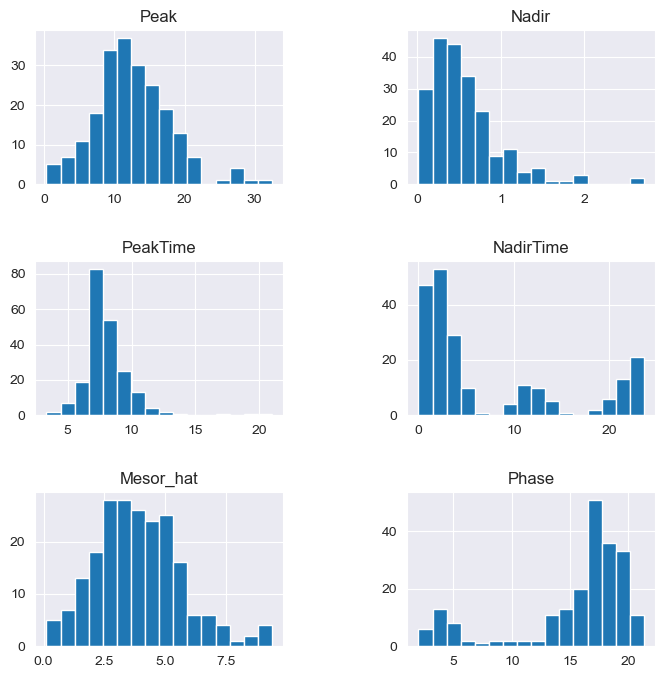

In [16]:
fig = person_features_df[['Peak','Nadir','PeakTime', 'NadirTime', 'Mesor_hat', 'Phase']].hist(figsize=(8, 8), bins=16)
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

In [17]:
person_features_df['BimodalEvening']

0      False
1       True
2       True
3       True
4       True
       ...  
208     True
209     True
210     True
211     True
212     True
Name: BimodalEvening, Length: 213, dtype: bool

In [18]:
unique_dates = highResDataUpdated['datetime'].unique()
date_frame = { 
    'dateTime': unique_dates,
    'next': pd.to_datetime(list(unique_dates[1:]) + [pd.NaT])
}
date_frame = pd.DataFrame(date_frame)
date_frame.to_csv('./data/high-resolution/date_frame.csv', index=False)

In [19]:
unique_master_ids = {
    'MasterID': highResDataUpdated['MasterID'].unique(),
}

person_cortisol_df = pd.DataFrame(unique_master_ids)  
person_cortisol_df['Aggregates'] = "Cortisol"
person_cortisol_df.to_csv('./data/high-resolution/person_cortisol.csv', index=False)

In [20]:
# [18oxoF|18OHF|Aldo|Cortisol|Cortisone|18OHCCS|DHEAS|21DOC|11DOC|CCS|aTHF|THF|aTHE|THE]

ids = [
    '0e5ee681-f1f8-432b-9b7f-3c8a9bf37ccc',
    '986c2526-bd34-4c47-bde0-1ce1b9e3dd2a',
    '331f9407-881d-4235-b880-48edf6c4d1a3',
    'fb4e4e82-7eeb-482f-a9a2-5f1ea4421f78',
    '7fca6ef2-8836-409b-a958-5287134aee49',
    'b04d90ba-5750-4666-a8ca-e02bbc4e2ec5',
    '5108b288-a0bc-4e12-bc22-870a8ef9789d',
    '36d1cef6-29bd-4c6a-be31-b1dc5718eca6',
    '7249ff28-22e3-4ad9-941d-872533f4b0e6',
    '7fa16bfd-eb60-4e59-884c-a8fb91a24e29',
    'e24296df-5350-4657-b3de-7182a580c9e4',
    '2dcfa2bd-5e70-442d-9ccc-761710bd435b',
    '77bd117a-5d7c-4851-b3a3-ba35b93d3741',
    '7f966adf-7c0c-4ac5-ad21-5285f12613b1',
    'ccfd930e-e90d-494a-b859-a69a86c61389',
    'a21ef33b-5df9-4525-89ed-41347cc3875b'
]

is_reading_of = pd.DataFrame({
    'MasterID': [],
    'IsReadingOf': []
})

master_ids = highResDataUpdated['MasterID'].unique()
master_id_len = len(master_ids)

for hormone_id in ids:
    unique_master_ids = {
        'MasterID': master_ids,
        'IsReadingOf': [hormone_id for _ in range(master_id_len)]
    }
    is_reading_of = pd.concat([is_reading_of, pd.DataFrame(unique_master_ids)], ignore_index=True)

is_reading_of.to_csv('./data/high-resolution/is_reading_of.csv', index=False)

In [21]:
healthy_phenotypes = pd.read_csv('./data/csvs/healthy-phenotype.csv/part-00000-72f2152f-7734-468b-9084-9357271e640a-c000.csv')
risk_factors = pd.read_csv('./data/csvs/risk-factor.csv/part-00000-9472904f-5ace-49a0-9444-c70c8ff4c3ca-c000.csv')
person_correlation = person_features_df.copy()

risk_factor_list = risk_factors['RiskFactorId'].unique().tolist()
healthy_phenotype_list = healthy_phenotypes['PhenoTypeId'].unique().tolist()

for phenotype_id in healthy_phenotype_list:
    if phenotype_id not in person_correlation.columns:
        person_correlation[phenotype_id] = 0
        
for risk_factor_id in risk_factor_list:
    if risk_factor_id not in person_correlation.columns:
        person_correlation[risk_factor_id] = 0


for index, row in healthy_phenotypes.iterrows():
    for phenotype_id in healthy_phenotype_list:
        if row['PhenoTypeId'] == phenotype_id:
            person_correlation.loc[person_correlation['MasterID'] == row['PersonId'], phenotype_id] = 1

for index, row in risk_factors.iterrows():
    for phenotype_id in risk_factor_list:
        if row['RiskFactorId'] == phenotype_id:
            person_correlation.loc[person_correlation['MasterID'] == row['PersonId'], phenotype_id] = 1

corr = person_correlation.corr(method='pearson')

corr.drop(columns=['MasterID','BMIHealthy','BMIOverweight','BMIUnderweight','NormalBP','HyperStage1BP','HyperStage2BP','PreHyperBP','Smoker','NonSmoker','HighWaistToHipRatio','LowWaistToHipRatio','MediumWaistToHipRatio'], inplace=True)
corr.drop(index=['MasterID','Mesor_hat','AmplitudeHat','Peak','NadirTime','Nadir','PeakTime','Phase','Morning','Afternoon','Evening','Night','MorningPeak','AfternoonPeak','EveningPeak','NightPeak','BimodalAfternoon','BimodalEvening'], inplace=True)
corr

,Mesor_hat,AmplitudeHat,Peak,Nadir,PeakTime,NadirTime,Phase,Morning,Afternoon,Evening,Night,MorningPeak,AfternoonPeak,EveningPeak,NightPeak,BimodalAfternoon,BimodalEvening
BMIHealthy,0.173210,-0.050767,0.177388,0.105330,-0.098279,0.017075,-0.012372,0.132913,0.096288,0.125768,0.141791,0.170283,0.115145,0.168751,0.119612,0.023555,-0.013532
NormalBP,0.077251,-0.074246,0.066828,0.039142,0.132343,-0.017819,-0.042070,0.072932,0.056549,0.121791,0.035543,0.060325,0.042222,0.081548,-0.061170,-0.018694,0.062303
LowWaistToHipRatio,0.011033,-0.112852,0.027166,-0.006971,-0.051976,-0.126791,0.049083,0.021954,0.120466,0.128746,0.109048,0.027217,0.130445,0.143926,0.015129,0.085133,-0.144824
NonSmoker,0.071460,-0.019212,-0.015002,0.021225,-0.078005,-0.045173,0.041946,0.036443,0.012981,-0.048559,-0.016552,-0.010061,-0.061376,-0.032666,0.106943,-0.057812,-0.014960
HyperStage1BP,-0.069304,0.065743,-0.059644,-0.042719,-0.123726,0.022285,0.049420,-0.080403,-0.142558,-0.142297,-0.029093,-0.058262,-0.089168,-0.125218,0.034499,0.060318,0.086347
Smoker,-0.071460,0.019212,0.015002,-0.021225,0.078005,0.045173,-0.041946,-0.036443,-0.012981,0.048559,0.016552,0.010061,0.061376,0.032666,-0.106943,0.057812,0.014960
BMIOverweight,-0.217582,0.082121,-0.212778,-0.150580,0.088495,-0.009827,0.012204,-0.176487,-0.144942,-0.200895,-0.177755,-0.206007,-0.149937,-0.236027,-0.140522,-0.035407,0.046576
HyperStage2BP,0.062470,-0.049957,0.043533,0.217276,0.044367,0.132563,-0.023346,0.090585,0.095397,0.105065,0.166968,0.043979,0.076826,0.053123,0.022450,0.010648,0.015243
PreHyperBP,-0.029502,0.038579,-0.023005,-0.036270,-0.064823,-0.012944,0.004756,-0.023316,0.035042,-0.040105,-0.035630,-0.017269,0.015201,0.001415,0.047012,-0.026856,-0.133664
MediumWaistToHipRatio,0.012603,0.057158,0.016803,-0.014889,-0.068964,-0.009827,-0.022266,0.016150,-0.080878,-0.082818,-0.068990,0.015952,-0.075714,-0.083656,-0.007341,0.032536,0.095208


<Axes: >

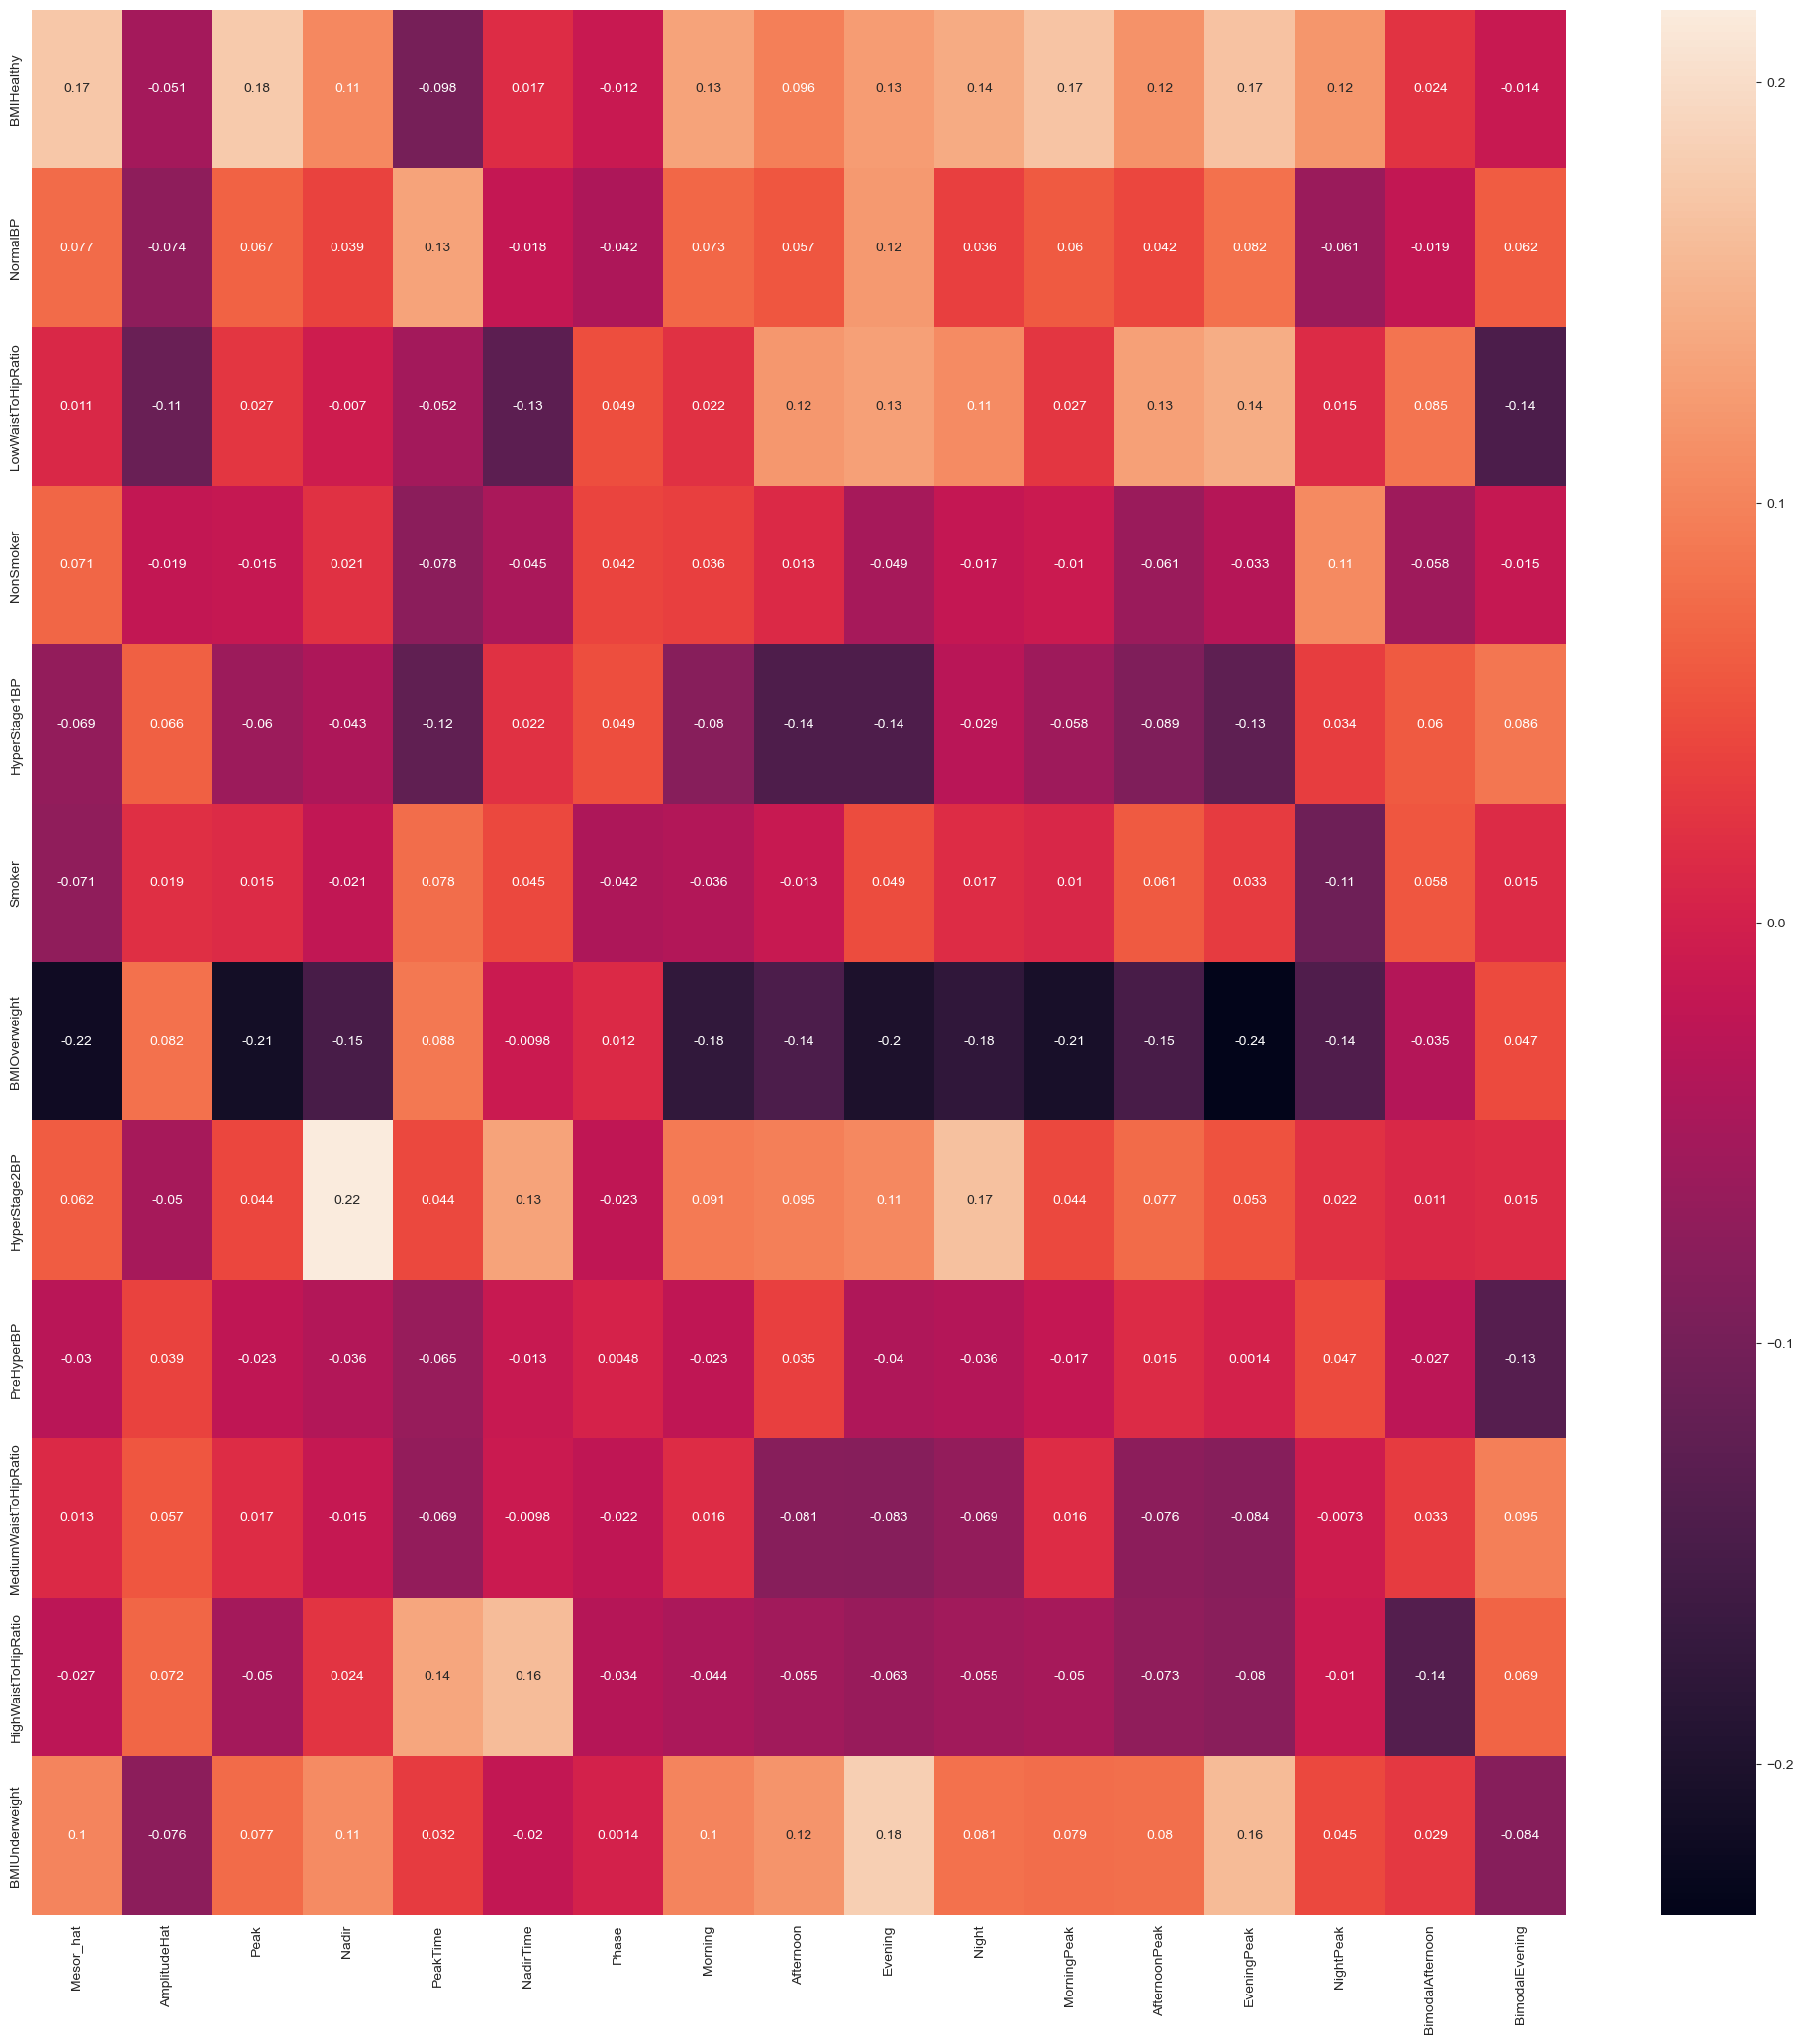

In [22]:
plt.figure(figsize = (25, 25))
# and use seaborn to fill this figure with a heatmap
sns.heatmap(corr, annot = True)

In [23]:
peaks = corr.copy()
peaks.drop(columns=['AmplitudeHat','Nadir','PeakTime','NadirTime','Phase','BimodalEvening','BimodalAfternoon'], inplace=True)

<Axes: >

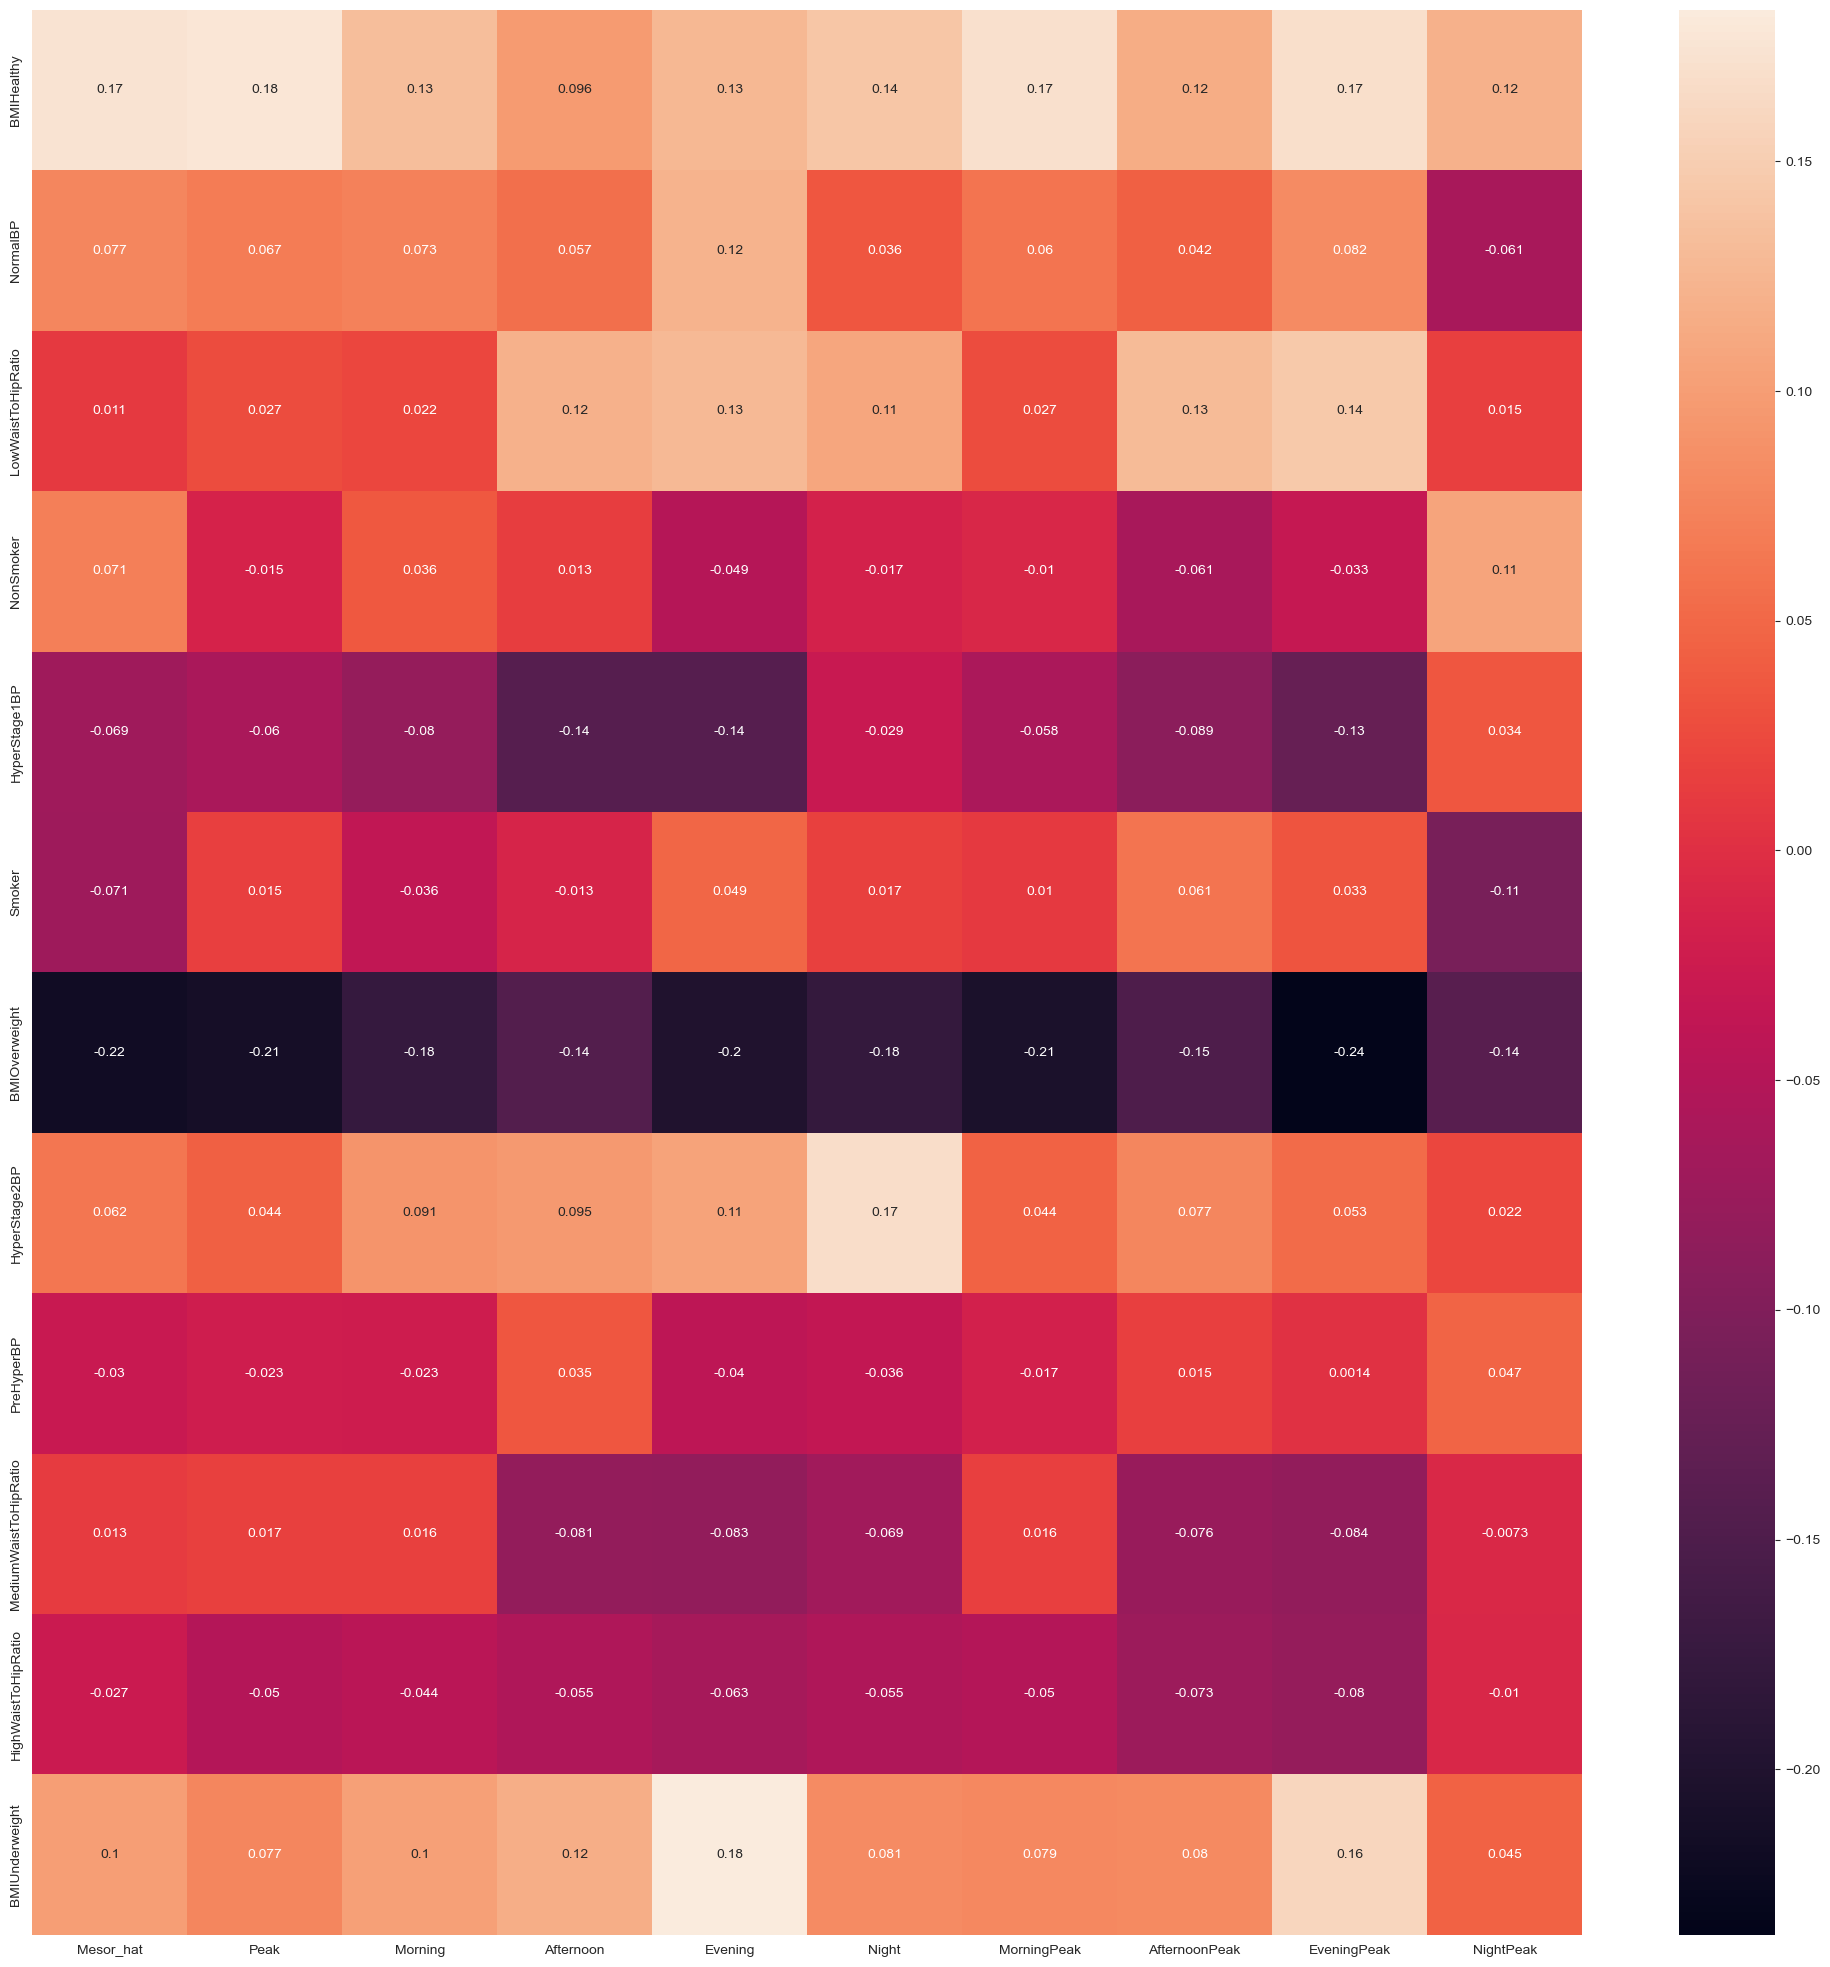

In [24]:
plt.figure(figsize = (25, 25))
# and use seaborn to fill this figure with a heatmap
sns.heatmap(peaks, annot = True)

In [25]:
nadirs = corr.copy()
nadirs.drop(columns=['Mesor_hat','Peak','AmplitudeHat','PeakTime','NadirTime','Phase','BimodalEvening','BimodalAfternoon','Morning','MorningPeak','Afternoon','Af'], inplace=True)
nadirs

KeyError: "['Af'] not found in axis"

In [ ]:
# and plot our figure size
plt.figure(figsize = (25, 25))
# and use seaborn to fill this figure with a heatmap
sns.heatmap(corr, annot = True)